# S3 — Exploratory data analysis

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/enriquea/ZebraQ/blob/main/lessons-py/S3_Exploratory_Data_Analysis.ipynb)

**ZebraQ — Introduction to Python and bulk RNA-seq data analysis**

Exploratory data analysis (EDA) means summarising a dataset's main
characteristics, mostly visually, before any formal modelling. It is how you
find out what your data can tell you — and how you catch problems early.

By the end of this notebook you will be able to summarise a table numerically,
produce the standard plots with seaborn, and run a two-group comparison.

## 0. Setup

In [1]:
import sys
import subprocess

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    subprocess.run(
        [sys.executable, "-m", "pip", "-q", "install",
         "pandas", "numpy", "seaborn", "scipy", "session-info"],
        check=True,
    )

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

RAW = "https://raw.githubusercontent.com/enriquea/ZebraQ/main/data/"


def data_path(fname):
    local = Path("../data") / fname
    return local if local.exists() else RAW + fname


# A consistent look for every figure in this notebook
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (7, 4.5)
plt.rcParams["figure.dpi"] = 110

print(f"seaborn {sns.__version__}")

seaborn 0.13.2


## 1. Load the data

These are genes associated with congenital heart disease (CHD), annotated with
constraint metrics from gnomAD.

In [2]:
chd = pd.read_csv(data_path("chd_genes.annotations.tsv"), sep="\t")
print(f"{chd.shape[0]} genes x {chd.shape[1]} columns")
chd.head()

276 genes x 10 columns


,gene_symbol,category,pLI,plof,gene_length,obs_lof,obs_syn,exp_lof,exp_syn,chromosome
0,ABCC9,syndromic,9.352400e-09,0.482,144002,30,298,84.399,298.160,12
1,ABL1,syndromic,9.999800e-01,0.176,173730,3,325,44.108,314.370,9
2,ACAD9,syndromic,4.525600e-08,0.814,36472,17,147,31.321,144.410,3
3,ACTA2,nonsyndromic,9.301700e-01,0.364,56317,2,72,17.293,84.674,10
4,ACTB,syndromic,9.856400e-01,0.232,36634,0,190,12.858,96.859,7


### 1.1 First look

Always run these three before anything else.

In [3]:
print("--- .info() : columns, dtypes, missing values ---")
chd.info()

--- .info() : columns, dtypes, missing values ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 276 entries, 0 to 275
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   gene_symbol  276 non-null    object 
 1   category     276 non-null    object 
 2   pLI          276 non-null    float64
 3   plof         276 non-null    float64
 4   gene_length  276 non-null    int64  
 5   obs_lof      276 non-null    int64  
 6   obs_syn      276 non-null    int64  
 7   exp_lof      276 non-null    float64
 8   exp_syn      276 non-null    float64
 9   chromosome   276 non-null    object 
dtypes: float64(4), int64(3), object(3)
memory usage: 21.7+ KB


In [4]:
print("--- .describe() : summary of every numeric column ---")
chd.describe().round(3)

--- .describe() : summary of every numeric column ---


,pLI,plof,gene_length,obs_lof,obs_syn,exp_lof,exp_syn
count,276.000,276.000,276.000,276.000,276.000,276.000,276.000
mean,0.498,0.571,98627.112,13.906,232.851,46.123,216.033
std,0.467,0.419,132728.926,20.952,244.354,43.561,210.585
min,0.000,0.032,1683.000,0.000,0.000,0.411,0.000
25%,0.000,0.207,18339.000,2.000,90.750,18.129,89.744
50%,0.502,0.482,46926.000,6.000,142.500,29.997,133.245
75%,0.999,0.860,129502.500,17.000,290.500,58.990,276.450
max,1.000,1.849,1180561.000,141.000,2103.000,240.670,1299.600


In [5]:
print("--- how many genes per category? ---")
print(chd["category"].value_counts())
print(f"\nmissing values anywhere: {chd.isna().sum().sum()}")

--- how many genes per category? ---
category
syndromic       219
nonsyndromic     57
Name: count, dtype: int64

missing values anywhere: 0


## 2. Summary statistics

We look at **pLI** — the probability that a gene is intolerant to loss of one
copy. Values near 1 mean the gene is essential.

In [6]:
pli = chd["pLI"]

print(f"mean    : {pli.mean():.4f}")
print(f"median  : {pli.median():.4f}")
print(f"std     : {pli.std():.4f}")
print(f"min     : {pli.min():.4f}")
print(f"max     : {pli.max():.4f}")
print("\nall at once, with .describe():")
print(pli.describe())

mean    : 0.4975
median  : 0.5015
std     : 0.4665
min     : 0.0000
max     : 1.0000

all at once, with .describe():
count    2.760000e+02
mean     4.975205e-01
std      4.665019e-01
min      1.594300e-68
25%      4.440975e-08
50%      5.015000e-01
75%      9.991125e-01
max      1.000000e+00
Name: pLI, dtype: float64


> ### ⚠️ A real difference from R
> pandas' `.std()` uses the **sample** standard deviation (divides by n-1),
> matching R's `sd()`. But NumPy's `np.std()` uses the **population** version
> (divides by n) by default. On the same data they give different answers.

In [7]:
print(f"pandas  pli.std()          : {pli.std():.6f}   <- matches R's sd()")
print(f"numpy   np.std(pli)        : {np.std(pli):.6f}   <- different!")
print(f"numpy   np.std(pli, ddof=1): {np.std(pli, ddof=1):.6f}   <- now it matches")

pandas  pli.std()          : 0.466502   <- matches R's sd()
numpy   np.std(pli)        : 0.465656   <- different!
numpy   np.std(pli, ddof=1): 0.466502   <- now it matches


## 3. Visualisation

### 3.1 Histogram — the distribution of one variable

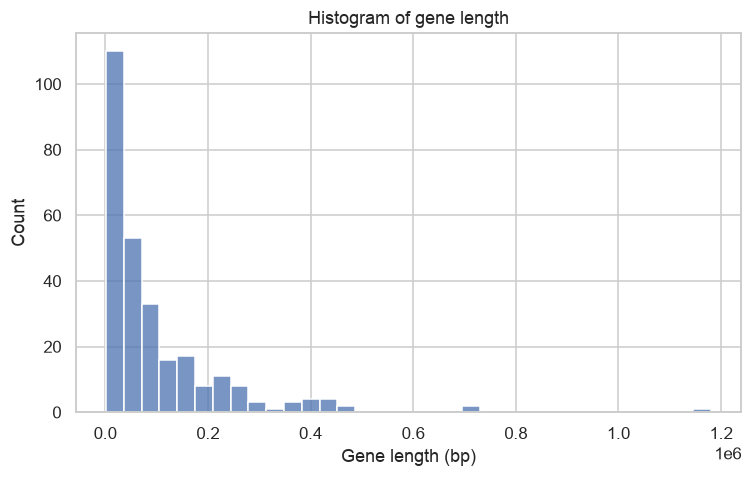

In [8]:
fig, ax = plt.subplots()
sns.histplot(data=chd, x="gene_length", ax=ax)
ax.set(title="Histogram of gene length", xlabel="Gene length (bp)", ylabel="Count")
plt.tight_layout()
plt.show()

The distribution is heavily right-skewed — a few enormous genes stretch the axis
and squash everything else. A log scale makes the shape readable:

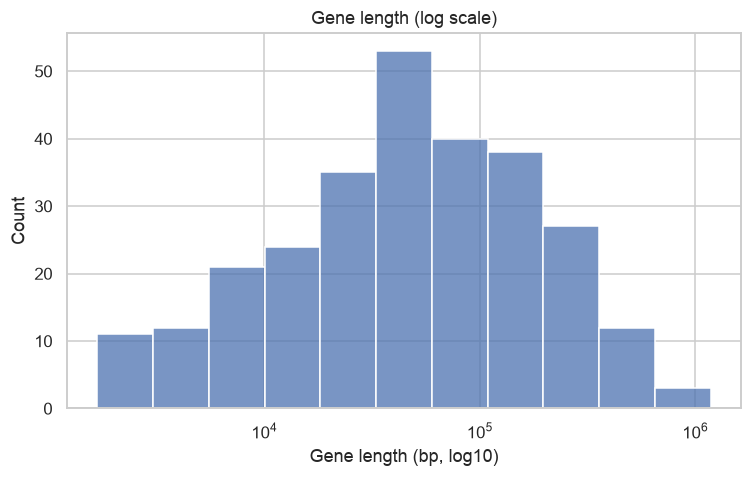

In [9]:
fig, ax = plt.subplots()
sns.histplot(data=chd, x="gene_length", log_scale=True, ax=ax)
ax.set(title="Gene length (log scale)", xlabel="Gene length (bp, log10)", ylabel="Count")
plt.tight_layout()
plt.show()

> **In R (ggplot2):**
> ```r
> ggplot(chd_genes, aes(x = gene_length)) + geom_histogram()
> ```
> seaborn's `data=` / `x=` arguments play the role of ggplot's `aes()`.

### 3.2 Boxplot — a distribution split by group

A boxplot shows the median, the quartiles, and the outliers.

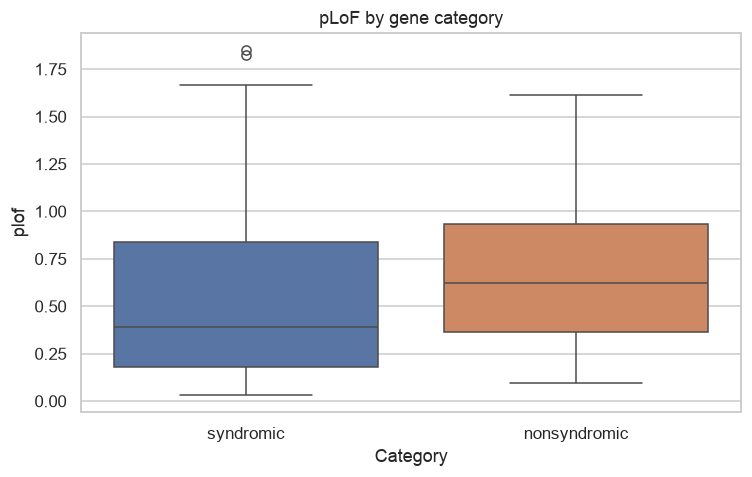

In [10]:
fig, ax = plt.subplots()
sns.boxplot(data=chd, x="category", y="plof", hue="category", legend=False, ax=ax)
ax.set(title="pLoF by gene category", xlabel="Category", ylabel="plof")
plt.tight_layout()
plt.show()

### 3.3 Scatter plot — two variables against each other

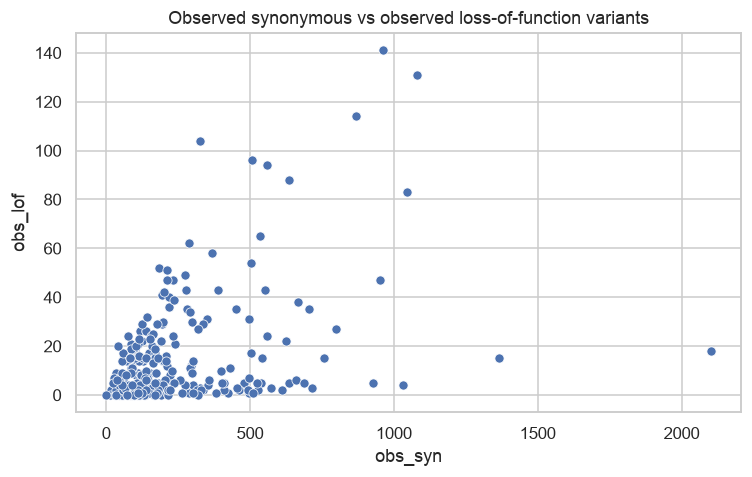

In [11]:
fig, ax = plt.subplots()
sns.scatterplot(data=chd, x="obs_syn", y="obs_lof", ax=ax)
ax.set(title="Observed synonymous vs observed loss-of-function variants")
plt.tight_layout()
plt.show()

### 3.4 Scatter with a regression line and a correlation coefficient

`sns.regplot` draws the line; `scipy.stats.pearsonr` gives us r and its p-value
to annotate the panel.

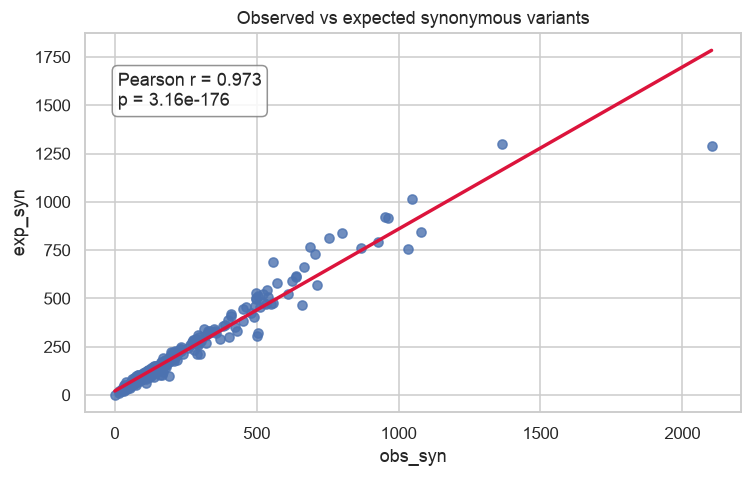

Pearson  r = 0.9729  (p = 3.155e-176)
Spearman r = 0.9832  (p = 2.348e-204)


In [12]:
x, y = chd["obs_syn"], chd["exp_syn"]
r, p = stats.pearsonr(x, y)

fig, ax = plt.subplots()
sns.regplot(x=x, y=y, ci=None, line_kws={"color": "crimson"}, ax=ax)
ax.set(title="Observed vs expected synonymous variants",
       xlabel="obs_syn", ylabel="exp_syn")
ax.annotate(
    f"Pearson r = {r:.3f}\np = {p:.2e}",
    xy=(0.05, 0.90), xycoords="axes fraction",
    va="top", bbox=dict(boxstyle="round", fc="white", ec="grey", alpha=0.85),
)
plt.tight_layout()
plt.show()

print(f"Pearson  r = {r:.4f}  (p = {p:.3e})")
rs, ps = stats.spearmanr(x, y)
print(f"Spearman r = {rs:.4f}  (p = {ps:.3e})")

> **In R:** `geom_smooth(method = "lm")` plus `ggpubr::stat_cor()`.
> There is no single seaborn call that adds the coefficient, so we compute it
> and annotate — which also means we know exactly what was calculated.

### 3.5 Density plot — a smoothed histogram, one curve per group

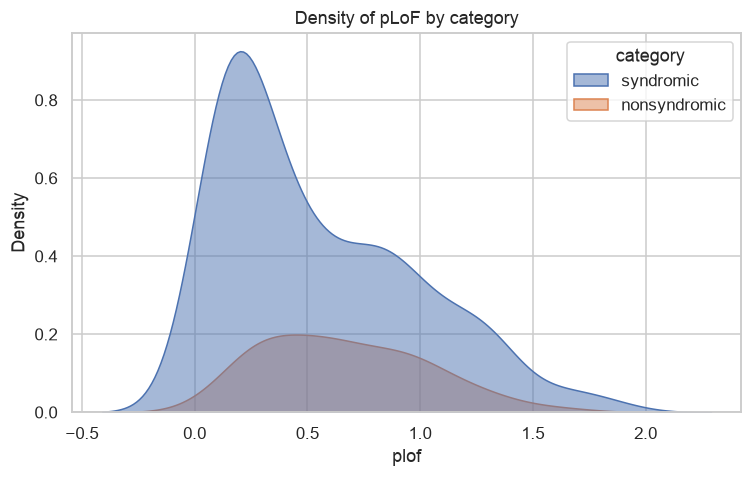

In [13]:
fig, ax = plt.subplots()
sns.kdeplot(data=chd, x="plof", hue="category", fill=True, alpha=0.5, ax=ax)
ax.set(title="Density of pLoF by category", xlabel="plof")
plt.tight_layout()
plt.show()

### 3.6 Bar plots — counting things

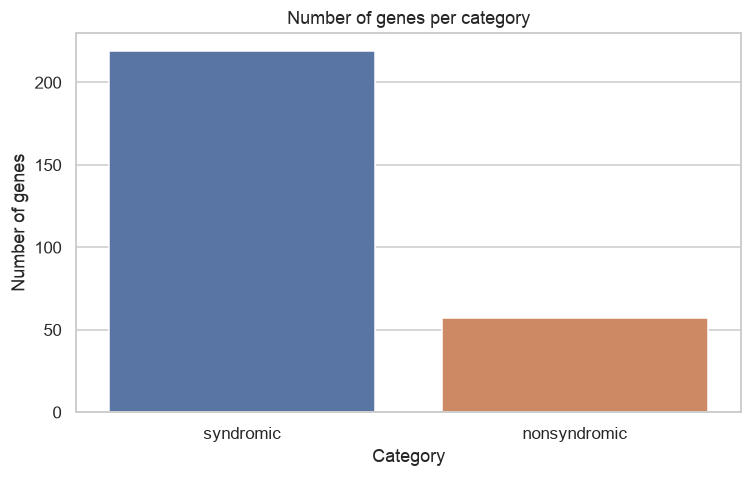

In [14]:
fig, ax = plt.subplots()
sns.countplot(data=chd, x="category", hue="category", legend=False, ax=ax)
ax.set(title="Number of genes per category", xlabel="Category", ylabel="Number of genes")
plt.tight_layout()
plt.show()

Counting by chromosome exposes the ordering problem from S1. Read as plain text,
chromosome 10 sorts before chromosome 2:

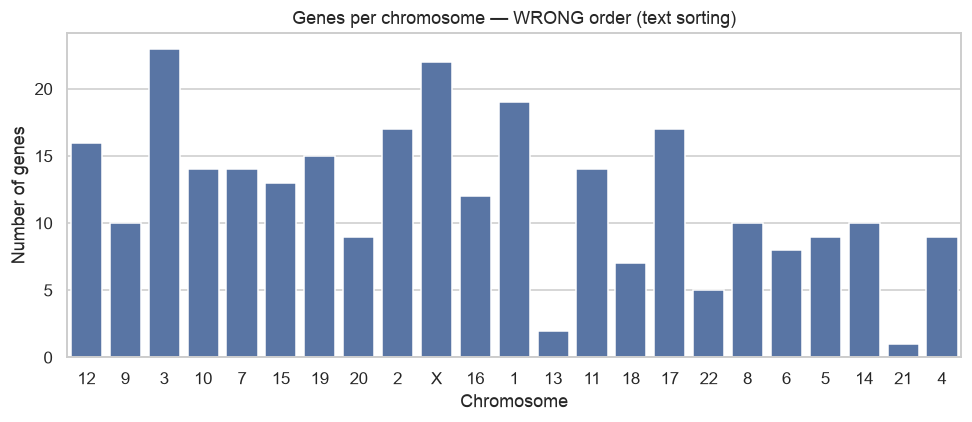

In [15]:
fig, ax = plt.subplots(figsize=(9, 4))
sns.countplot(data=chd, x="chromosome", ax=ax)
ax.set(title="Genes per chromosome — WRONG order (text sorting)",
       xlabel="Chromosome", ylabel="Number of genes")
plt.tight_layout()
plt.show()

The fix is an **ordered Categorical**, exactly like `factor(levels = ...)` in R:

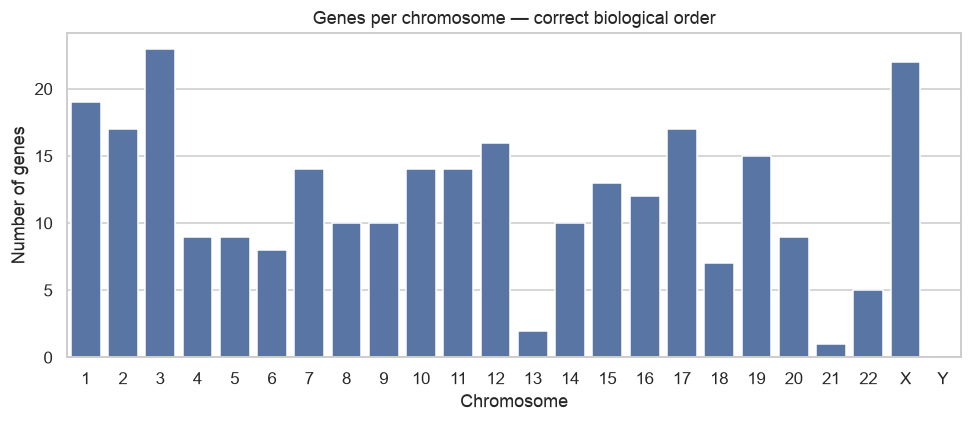

Note: no CHD gene in this table sits on chromosome Y, so that bar is empty.
Keeping Y in the category list is deliberate — the axis then matches every
other figure you might make from a different gene set.


In [16]:
chrom_order = [str(i) for i in range(1, 23)] + ["X", "Y"]
chd["chromosome"] = pd.Categorical(chd["chromosome"].astype(str),
                                   categories=chrom_order, ordered=True)

fig, ax = plt.subplots(figsize=(9, 4))
sns.countplot(data=chd, x="chromosome", order=chrom_order, ax=ax)
ax.set(title="Genes per chromosome — correct biological order",
       xlabel="Chromosome", ylabel="Number of genes")
plt.tight_layout()
plt.show()

print("Note: no CHD gene in this table sits on chromosome Y, so that bar is empty.")
print("Keeping Y in the category list is deliberate — the axis then matches every")
print("other figure you might make from a different gene set.")

## 4. Statistical tests

We ask whether pLI differs between syndromic and non-syndromic CHD genes.

- **t-test** — compares the *means*. Assumes roughly normal data.
- **Mann-Whitney U** — compares the *distributions* by rank. Makes no normality
  assumption. This is what R calls `wilcox.test` for two independent samples.

In [17]:
syndromic = chd.loc[chd["category"] == "syndromic", "pLI"]
nonsyndromic = chd.loc[chd["category"] == "nonsyndromic", "pLI"]

print(f"syndromic     : n = {len(syndromic):3d}, mean pLI = {syndromic.mean():.4f}")
print(f"nonsyndromic  : n = {len(nonsyndromic):3d}, mean pLI = {nonsyndromic.mean():.4f}")

syndromic     : n = 219, mean pLI = 0.5365
nonsyndromic  : n =  57, mean pLI = 0.3479


> ### ⚠️ `equal_var` matters
> R's `t.test()` defaults to **Welch's** t-test, which does *not* assume the two
> groups have equal variance. SciPy's `ttest_ind` defaults to the opposite.
> Pass `equal_var=False` to reproduce R's default.

In [18]:
t_welch = stats.ttest_ind(syndromic, nonsyndromic, equal_var=False)
t_student = stats.ttest_ind(syndromic, nonsyndromic, equal_var=True)

print(f"Welch   (matches R's t.test default) : t = {t_welch.statistic:.4f}, p = {t_welch.pvalue:.4f}")
print(f"Student (scipy default)              : t = {t_student.statistic:.4f}, p = {t_student.pvalue:.4f}")

Welch   (matches R's t.test default) : t = 2.8937, p = 0.0047
Student (scipy default)              : t = 2.7509, p = 0.0063


In [19]:
u = stats.mannwhitneyu(syndromic, nonsyndromic, alternative="two-sided")
print(f"Mann-Whitney U (R's wilcox.test): U = {u.statistic:.1f}, p = {u.pvalue:.4f}")

Mann-Whitney U (R's wilcox.test): U = 8092.5, p = 0.0006


### 4.1 The same test on the pLoF metric

In [20]:
plof_syn = chd.loc[chd["category"] == "syndromic", "plof"]
plof_non = chd.loc[chd["category"] == "nonsyndromic", "plof"]
u_plof = stats.mannwhitneyu(plof_syn, plof_non, alternative="two-sided")
print(f"pLoF, Mann-Whitney U: U = {u_plof.statistic:.1f}, p = {u_plof.pvalue:.4g}")

pLoF, Mann-Whitney U: U = 4786.0, p = 0.006717


## 5. A boxplot with the test result on it

R's `ggpubr::stat_compare_means()` adds this automatically. In Python we draw the
bracket ourselves — a few more lines, but nothing is hidden from you.

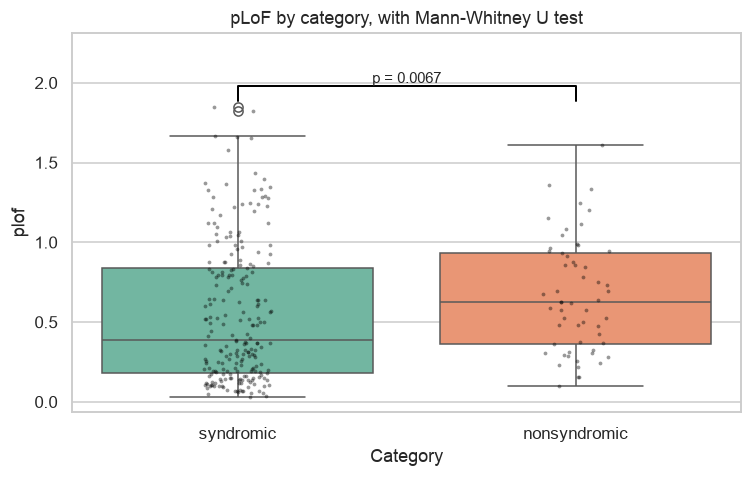

In [21]:


def annotate_significance(ax, x1, x2, y, p_value, height=0.04):
    """Draw a significance bracket between two categorical positions."""
    bar = y + height
    ax.plot([x1, x1, x2, x2], [y, bar, bar, y], lw=1.3, c="black")
    if p_value < 1e-4:
        label = f"p = {p_value:.1e}"
    elif p_value < 0.05:
        label = f"p = {p_value:.4f}"
    else:
        label = f"p = {p_value:.3f} (ns)"
    ax.text((x1 + x2) / 2, bar, label, ha="center", va="bottom", fontsize=10)


fig, ax = plt.subplots()
sns.boxplot(data=chd, x="category", y="plof", hue="category",
            legend=False, palette="Set2", ax=ax)
sns.stripplot(data=chd, x="category", y="plof", color="black",
              size=2.5, alpha=0.4, ax=ax)

top = chd["plof"].max()
annotate_significance(ax, 0, 1, top * 1.02, u_plof.pvalue, height=top * 0.05)
ax.set(title="pLoF by category, with Mann-Whitney U test",
       xlabel="Category", ylabel="plof", ylim=(None, top * 1.25))
plt.tight_layout()
plt.show()

## 6. Exercises

1. Plot the distribution of `pLI`. Is it symmetric? What does that suggest about
   using a t-test on it?
2. Make a scatter plot of `exp_lof` against `obs_lof`, coloured by category.
3. Compute the median `gene_length` for each category.
4. Test whether `gene_length` differs between the two categories. Which test did
   you choose, and why?
5. Which chromosome carries the most CHD genes? Does that stay true after you
   divide by the number of genes on each chromosome?

*(Question 5 is the interesting one — raw counts are almost always confounded by
how big the thing you are counting in is.)*

## 7. Session information

In [22]:
import session_info

session_info.show()